# **Bank Telemarketing Dataset -- Client EDA Approach**

In [49]:
## Import commonly used libraries
import pandas as pd 
import numpy as np  
import sidetable
import sklearn
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob
from itertools import combinations

## Display Setting

In [50]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')

In [51]:
file = []
data_path = Path.cwd().parent.joinpath("data", "raw")
for f in data_path.glob("*"):
    file.append(f.name)

print(file)

['.gitkeep', 'bank-additional-full.csv', 'bank-additional-names.txt', 'bank-full.csv', 'info.txt']


In [52]:
tele_df = pd.read_csv(data_path.joinpath("bank-additional-full.csv"), sep=';')
tele_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [53]:
tele_df.shape

(41188, 21)

In [54]:
# Remove whitespaces, ., spaces and lowercase column names
tele_df.columns = tele_df.columns.str.strip().str.replace(".", " ").str.replace(" ", "_").str.lower()
tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [55]:
tele_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [56]:
# Check Missing values
import sidetable
miss_df = tele_df.stb.missing()
miss_df.query("percent > 0")

,missing,total,percent


**No Missing Value in give dataset for numeric variables, will explore this.**

**Missing Attribute Values for Categorical Variables:** There are several missing values in some categorical attributes, all coded with the "unknown" label. These missing values can be treated as a possible class label or using deletion or imputation techniques.


**Bank Client Data Description:**

- **age**: Age of the client (numeric)
- **job**: Type of job (categorical: 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown')
- **marital**: Marital status (categorical: 'divorced', 'married', 'single', 'unknown')
- **education**: Level of education (categorical: 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown')
- **default**: Whether the client has credit in default (binary: 'no', 'yes', 'unknown')
- **housing**: Whether the client has a housing loan (binary: 'no', 'yes', 'unknown')
- **loan**: Whether the client has a personal loan (binary: 'no', 'yes', 'unknown')


## **Formatting and Consistency Check**

In [57]:
dtype_df = pd.DataFrame({
    'dtype': tele_df.dtypes,
    'nunique': tele_df.nunique(),
    'unique' : [tele_df[col].unique() for col in tele_df.columns]
}, index=tele_df.columns)
dtype_df

,dtype,nunique,unique
age,int64,78,"[56, 57, 37, 40, 45, 59, 41, 24, 25, 29, 35, 5..."
job,object,12,"[housemaid, services, admin., blue-collar, tec..."
marital,object,4,"[married, single, divorced, unknown]"
education,object,8,"[basic.4y, high.school, basic.6y, basic.9y, pr..."
default,object,3,"[no, unknown, yes]"
housing,object,3,"[no, yes, unknown]"
loan,object,3,"[no, yes, unknown]"
contact,object,2,"[telephone, cellular]"
month,object,10,"[may, jun, jul, aug, oct, nov, dec, mar, apr, ..."
day_of_week,object,5,"[mon, tue, wed, thu, fri]"


# **Exploratory Data Analysis ---- bank client attributes**

**Target Variable**

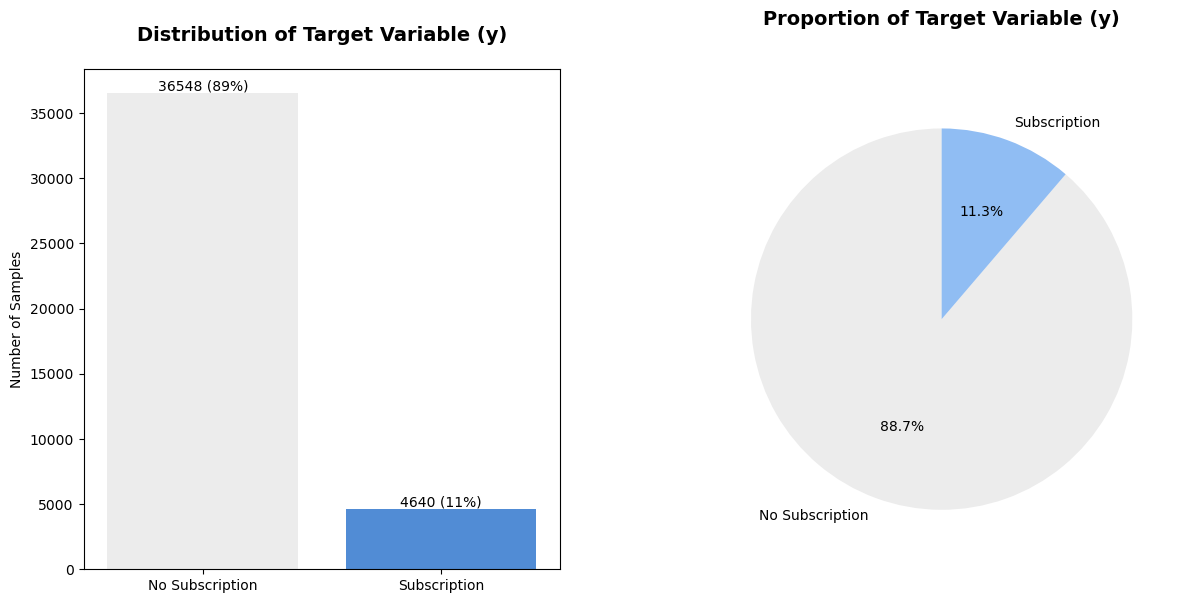

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# Countplot for target variable
sns.countplot(
    data=tele_df, x='y', 
    order=tele_df['y'].value_counts().index, 
    palette = ['#ececec', '#3B8AEB90'],
    ax=ax[0])

ax[0].set_title('Distribution of Target Variable (y)', fontsize=14, fontweight='bold', y=1.04)
ax[0].set_xlabel('')
ax[0].set_ylabel('Number of Samples')
ax[0].set_xticks([0, 1], labels = ['No Subscription', 'Subscription'], rotation=0)

# Add percentage labels on bars
for i, v in enumerate(tele_df['y'].value_counts()):
    percentage = 100 * v / len(tele_df)
    ax[0].text(i, v + 200, f"{v} ({percentage:.0f}%)", ha='center', fontsize=10)

# Pie chart for target variable
tele_df['y'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    colors = ['#ececec', "#3B8AEB90"], 
    startangle=90, labels = ['No Subscription', 'Subscription'],
    ax=ax[1])

ax[1].set_ylabel('')
ax[1].set_title('Proportion of Target Variable (y)', fontsize=14, fontweight='bold', y=1.10)

# Add layout adjustments
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

**Data is highly imbalanced, with a significant majority of customers not subscribing to the term deposit. This imbalance will need to be addressed in the modeling phase, possibly through techniques such as resampling or using algorithms that can handle class imbalance effectively.**

In [59]:
# Make y binary in next step:
tele_df['y_binary'] = tele_df['y'].map({'yes': 1, 'no':0})

### **Dimension Analysis**

In [60]:
tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'y_binary'],
      dtype='object')

In [61]:
## dimensions to be focus for eda
cols = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'y', 'y_binary']
client_df = tele_df[cols]

**Metric : Conversion Rate**

How to calculate : Conversion rate compute by total number of term deposit subscribers/ Total number of contact.

- What to do:
    - User defined function for 
        - univariate analysis of variables to compute total counts of contact of each categories and their respective conversion rate.
        - bivariate analysis of variables with another variables for total counts and conversion rate for hidden pattern and trend.
        - Cumulative sum of total contacts and yes responses of variable's categories.
        - statistical test for association between categorical variable and y (term-deposit)
    - compute year column as given dataset is ordered in may 2008 to nov 2010.
    - orderd month as natural order of months.


In [62]:
# Reorder months as per natural order
months = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
tele_df['months_order'] = pd.Categorical(tele_df['month'], categories=months, ordered=True)


In [63]:
# Here we just get an insight of how months are going one by one in the dataset.
# Just a remainder: the observations are ordered by date (from May 2008 to November 2010.
months_arr = [
    [i, m]
    for i, m in enumerate(tele_df['month'])
    if i==0 or m != tele_df['month'].iloc[i-1]    ## “Take this row if it’s the first row OR if the month changed compared to the previous row.”
]
months_arr = np.array(months_arr)


__We've got :__

__2008 : [0, 27690)__

__2009 : [27690, 39130)__

__2010 : [39130, 41188)__



In [64]:
tele_df['year'] = np.hstack((np.array([2008] * (27690 - 0)),
           np.array([2009] * (39130 - 27690)),
           np.array([2010] * (41188 - 39130))))

In [91]:
# Univariate analysis function for categorical variables with bar plots
def univariate_analysis_categorical_var(df, categorical_var, display_name):
    """Compute total count of customers contacted and percentage of customers who subscribed to a term deposit."""
    # Count of campaign for each category
    total_counts = df.groupby([categorical_var])['y'].value_counts().unstack().fillna(0)   
    total_counts['total'] = total_counts.sum(axis='columns')
    total_counts = total_counts.sort_values(by='total', ascending=False)
    total_counts['conversion_rate'] = (total_counts['yes'] / total_counts['total']).round(2)
    total_counts = total_counts.assign(
        cumsum_total_proportion = lambda x: (x['total'].cumsum() / x['total'].sum())*100,
        cumsum_yes_proportion = lambda x: (x['yes'].cumsum() / x['yes'].sum())*100
    )
    
    # Visualization
    fig, ax = plt.subplots(2, 1, sharex=True,figsize=(15, 8), dpi=100)
    colors = [(0.3, 0.8, 1), (0.6, 0.6, 1), '#0000FF']
    # plot for total campaigns
    x_pos = range(len(total_counts.index))
    ax[0].bar(x_pos, total_counts['total'], color=colors)
    ax[0].set_xticks(x_pos)
    ax[0].set_xticklabels(total_counts.index)
    ax[0].set_ylabel("Count")
    ax[0].set_title(display_name + ' Distribution', fontsize=14, fontweight='bold', y=1.04)
    for i, v in enumerate(total_counts['total']):
        ax[0].text(i, v + 200, f"{int(v)} ({(v/(total_counts['total'].sum(axis=0))):.0%})", ha='center', fontsize=10)

    # plot for successful subscriptions
    ax[1].bar(x_pos, total_counts['conversion_rate'], color=colors)
    ax[1].set_xticks(x_pos)
    ax[1].set_xticklabels(total_counts.index)
    ax[1].set_ylabel('Proportion')
    ax[1].set_title(display_name +" " + 'YES-proportion', fontsize=14, fontweight='bold', y=1.04)
    for i, v in enumerate(total_counts['conversion_rate']):
        ax[1].text(i, v , f"({total_counts['conversion_rate'].iloc[i]:.2f})", ha='center', fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)
    plt.show()

    return total_counts, fig



In [92]:
# Bivariate Analysis with Heatmaps
def plot_heatmap_bivariate_analysis(df, var1, var2, y_binary):
    """Plot heatmap for total observed and yes counts for given variables."""
    # Total counts
    total_counts = pd.crosstab(df[var1], df[var2], values=df[y_binary], aggfunc='count')
    # Yes counts
    yes_counts = pd.crosstab(df[var1], df[var2], values=df[y_binary], aggfunc='mean').round(2)

    # Plot heatmap
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    # Total observed heatmap
    scatter = sns.heatmap(total_counts, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax[0])
    colorbar = scatter.collections[0].colorbar
    colorbar.set_ticks([])
    ax[0].set_title(f'Total Observed Counts by\n{var1} and {var2}', fontsize=14, fontweight='bold', y=1.04)
    ax[0].tick_params(axis='y', rotation=25)
    ax[0].set_ylabel('')
    ax[0].set_xlabel('')

    # yes counts heamap
    heat_map = sns.heatmap(yes_counts, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=ax[1])
    colorbar = heat_map.collections[0].colorbar
    colorbar.set_ticks([])
    ax[1].set_title(f'Conversion Rate by\n{var1} and {var2}', fontsize=14, fontweight='bold', y=1.04)
    ax[1].tick_params(axis='y', rotation=25)
    ax[1].set_ylabel('')
    ax[1].set_xlabel('')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()

    return total_counts, yes_counts, fig

In [121]:
# Cumulative proportion of total contact and yes responses
def plot_cumsum_total_yes_response(df, feature_var, cumsum_total_var, cumsum_yes_var, fig=None, ax=None):
    if fig is None or ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(14,6))
    new_df = df.reset_index()

    # Left: Cumulative contribution of total contact
    ax[0].plot(new_df[feature_var], new_df[cumsum_total_var], marker='o', color="skyblue")
    ax[0].set_title("Cumulative Sum of Total Contacts", fontsize=14, fontweight='bold', y=1.05)
    ax[0].set_ylabel("Cumulative Proportion of Total")
    ax[0].tick_params(axis="x", rotation=45)


    # Right: Cumulative contribution of yes responses
    ax[1].plot(new_df[feature_var], new_df[cumsum_yes_var], marker="o", color="orange")
    ax[1].set_title("Cumulative Contribution of Yes Responses", fontsize=14, fontweight='bold', y=1.05)
    ax[1].set_ylabel("Cumulative Proportion of Yes")
    ax[1].tick_params(axis="x", rotation=45)

    for i, row in new_df.iterrows():
        ax[0].text(row[feature_var], row[cumsum_total_var]*1.05,
                    f"{row[cumsum_total_var]:.2f}%", ha='center', va='bottom', color='k', fontsize=10)
        ax[1].text(row[feature_var], row[cumsum_yes_var]*1.05,
                    f"{row[cumsum_yes_var]:.2f}%", ha='center', va='bottom', color='k', fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()


In [155]:
# Statistical test for relationship between categorical variables and y(term deposit)
def chi_square_categorical_y(data, feature_var, target_var):
    # Contingency table
    table = pd.crosstab(data[feature_var], data[target_var])

    # Chi-square test
    chi2, p, dof, expected = stats.chi2_contingency(table)

    # Compute Cramér's V
    n = table.sum().sum()
    k = min(table.shape)
    cramers_v = np.sqrt(chi2 / (n * (k - 1)))
    significance = 'small' if cramers_v < 0.1 else 'medium' if cramers_v < 0.3 else 'large' if cramers_v < 0.5 else 'very large'
    df = pd.DataFrame(
        [chi2, p, cramers_v, significance], index=['Chi-square', 'pvalue', 'cramers_v', 'effect_size'], columns=['statistical_values'])

    df = df.round(4)
    return df

In [160]:
def plot_odd_ratio_table(data, feature_var, target_var, baseline):
    """Compute odd ratios for categories of a given feature relative to a baseline."""

    # Contingency table
    table = pd.crosstab(data[feature_var], data[target_var])

    # Compute odds for each job
    table["odds"] = table["yes"] / table["no"]

    # Choose baseline
    if baseline is None:
        baseline = table.index[0]
    baseline_odds = table.loc[baseline, "odds"]

    # Compute odds ratio relative to baseline
    table[f"odds_ratio_vs_{baseline}"] = table["odds"] / baseline_odds

    # Create side-by-side figure
    fig, ax = plt.subplots(1, 2, figsize=(16,6))

    # Left side: table displayed as text
    ax[0].axis("off")  # hide axes
    table_display = table[["yes", "no", "odds", f"odds_ratio_vs_{baseline}"]]
    ax[0].table(cellText=table_display.round(2).values,
                rowLabels=table_display.index,
                colLabels=table_display.columns,
                loc="center")

    ax[0].set_title(f"Odds Ratio Table (vs {baseline})")

    # Right side: bar plot of odds ratios
    ax[1].bar(table.index, table[f"odds_ratio_vs_{baseline}"], color="skyblue")
    ax[1].axhline(1.0, color="red", linestyle="--", label=f"Baseline ({baseline})")
    ax[1].set_ylabel(f"Odds Ratio vs {baseline.capitalize()}")
    ax[1].set_title(f"Odds Ratios of YES-answers by {feature_var} Category")
    ax[1].tick_params(axis="x", rotation=45)
    ax[1].legend()

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()


**Dimension : `job`**

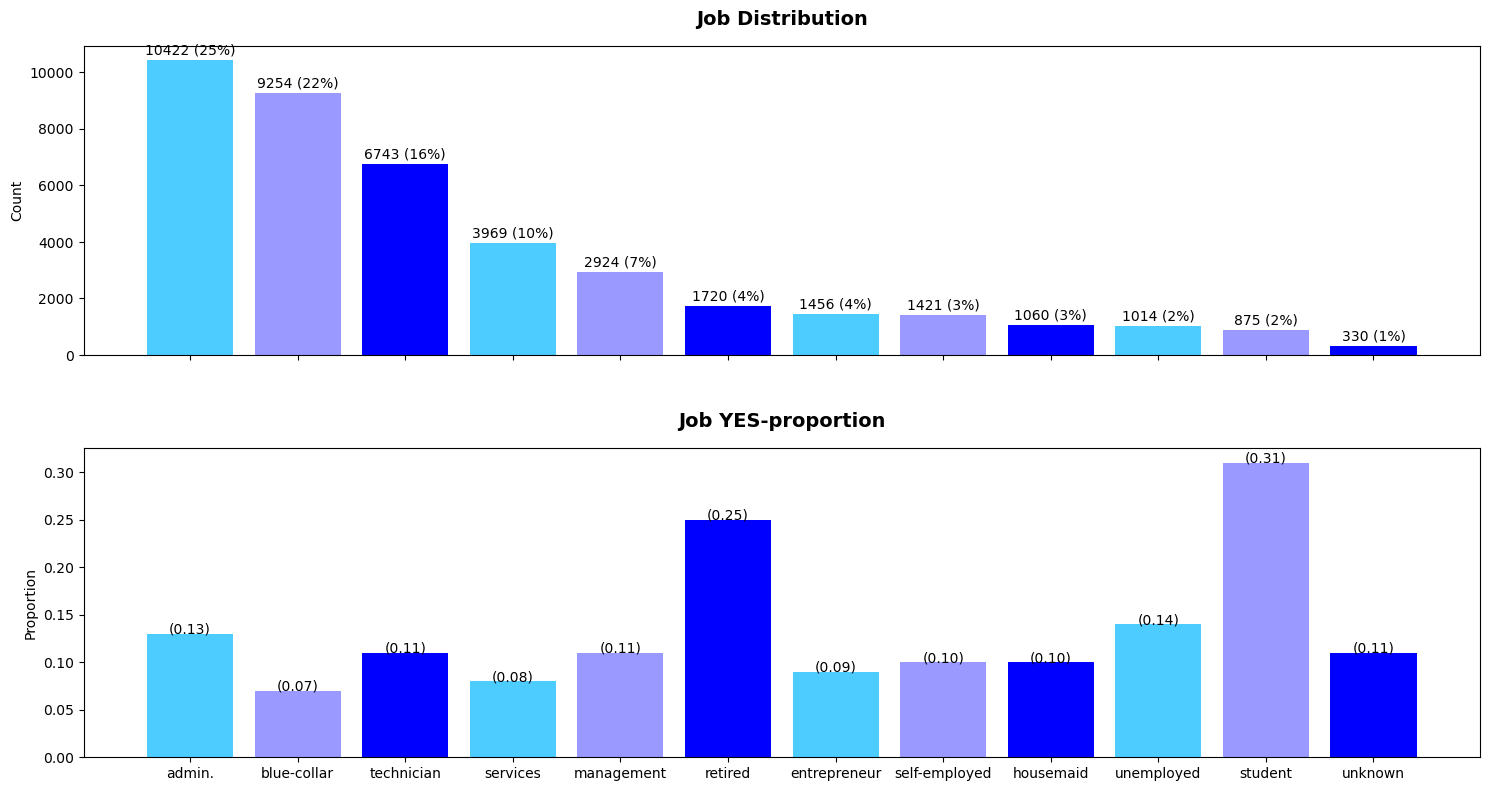

Figure(1500x800)


In [93]:
total_counts, fig = univariate_analysis_categorical_var(tele_df, 'job', 'Job')
print(fig)

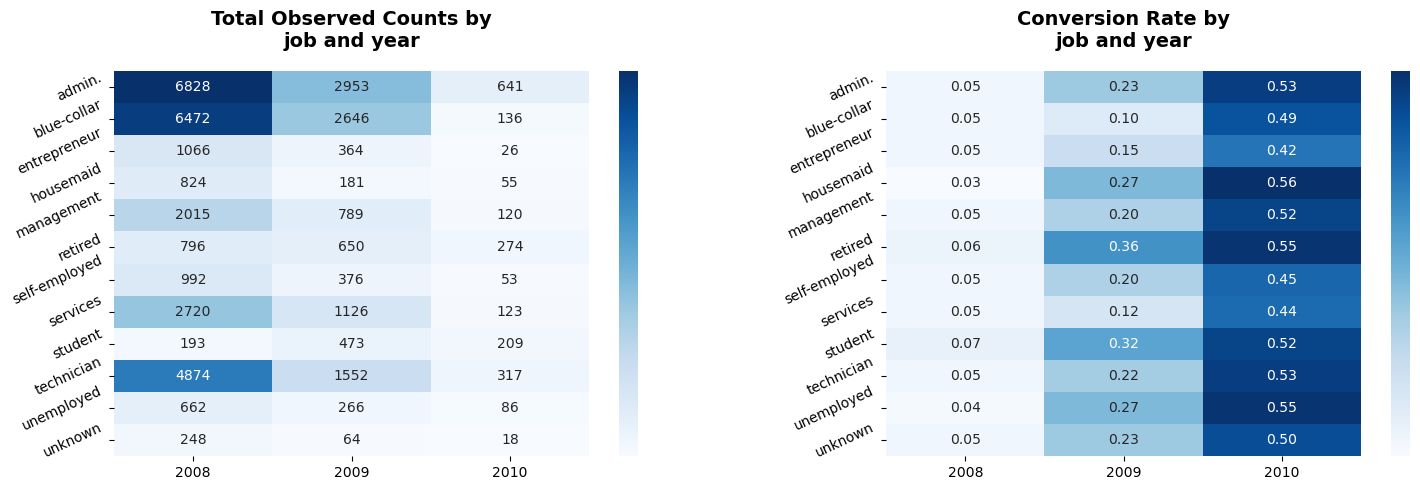

In [94]:
total_df, yes_df, fig = plot_heatmap_bivariate_analysis(tele_df, 'job', 'year', 'y_binary')

From the job YES-proportion plot we observed that **student and retired** are more likely to agree to subscribe for a term deposit, but considering heatmap plot we can see that this pattern works only for year 2009.
It also works for year 2008 but much less and this pattern disappears for year 2010. So, we can't confident about such patterns.

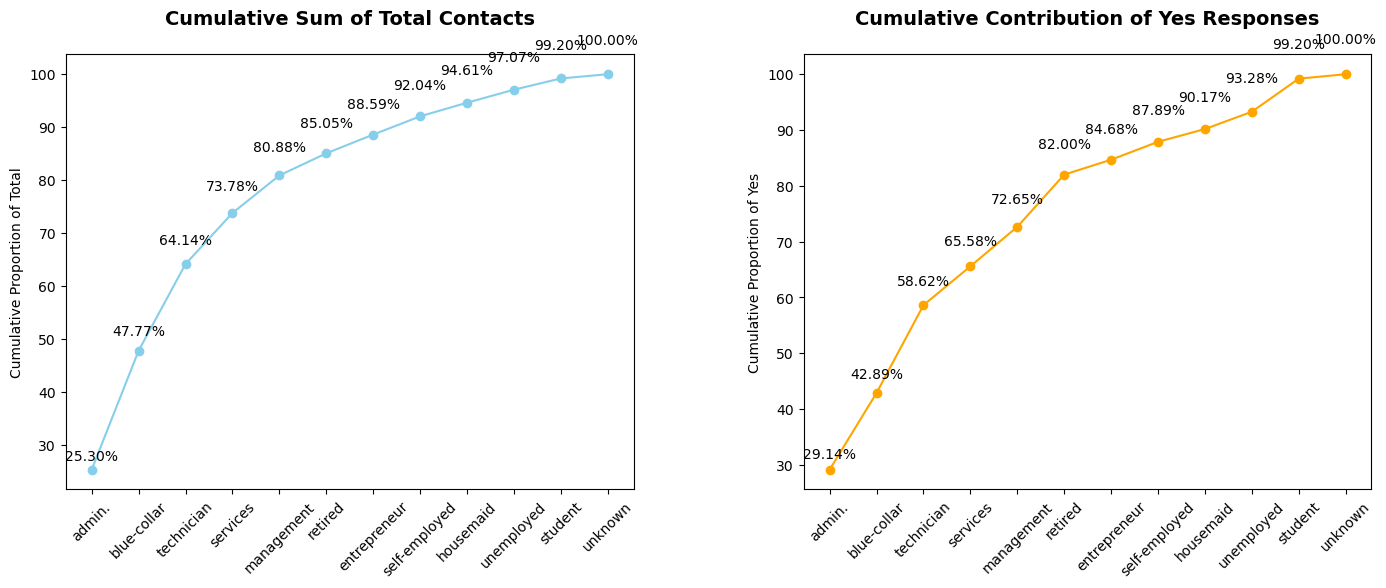

In [ ]:
# Cumulative sum of total counts and yes response by job category
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
plot_cumsum_total_yes_response(total_counts, 'job', 'cumsum_total_proportion', 'cumsum_yes_proportion', fig=fig, ax=ax);

In [ ]:
# Statistical test between job and y(term-deposit)
df = chi_square_categorical_y(tele_df, 'job', 'y')
df

,statistical_values
Chi-square,961.24244
pvalue,0.0
cramers_v,0.152768
effect_size,medium


- association between job and y is **medium**.

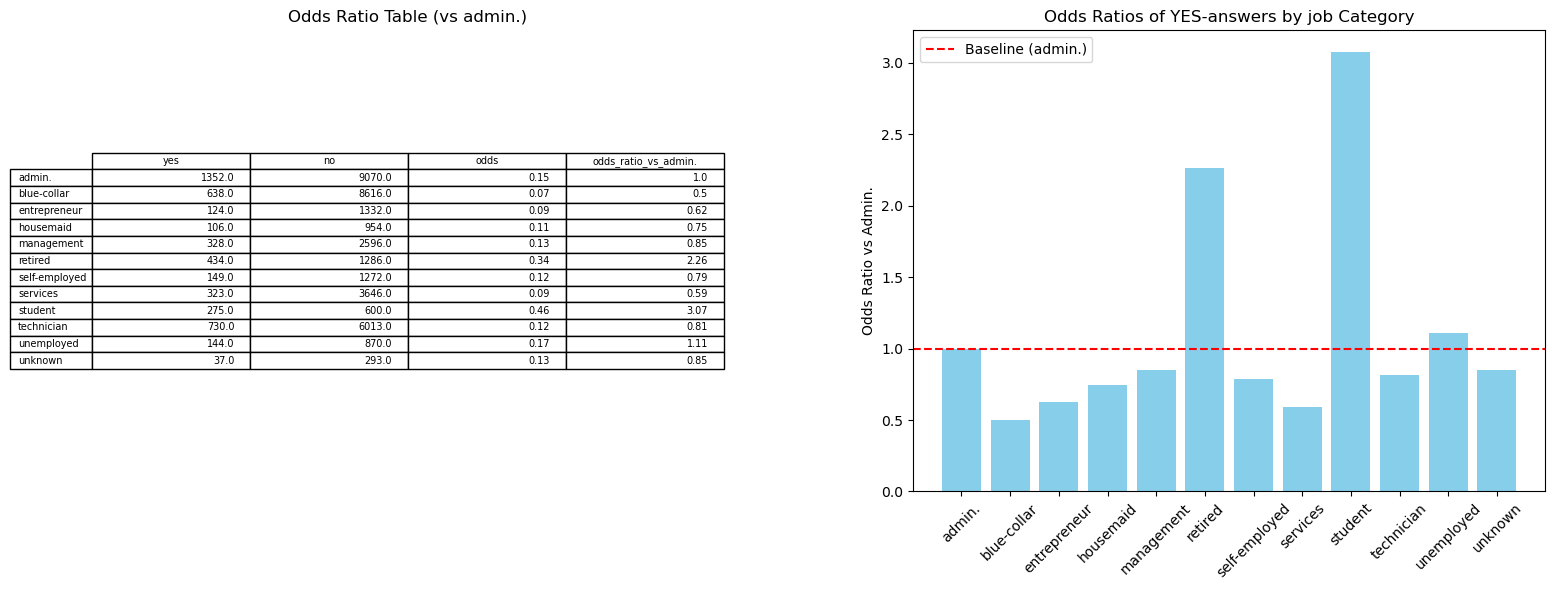

In [162]:
plot_odd_ratio_table(tele_df, 'job', 'y', 'admin.')

- **Student, retired and unemployed more likely to subscribe compared to admin. workers**

**Conclusion :**

- Most of the people in the dataset are from working class(admin + blue-collar-technician + services ~ 73%).
- Yes-proportion in the dataset hold by this working class ~ 66%.
- job type influences subscription, but the strength of the relationship is **medium**.

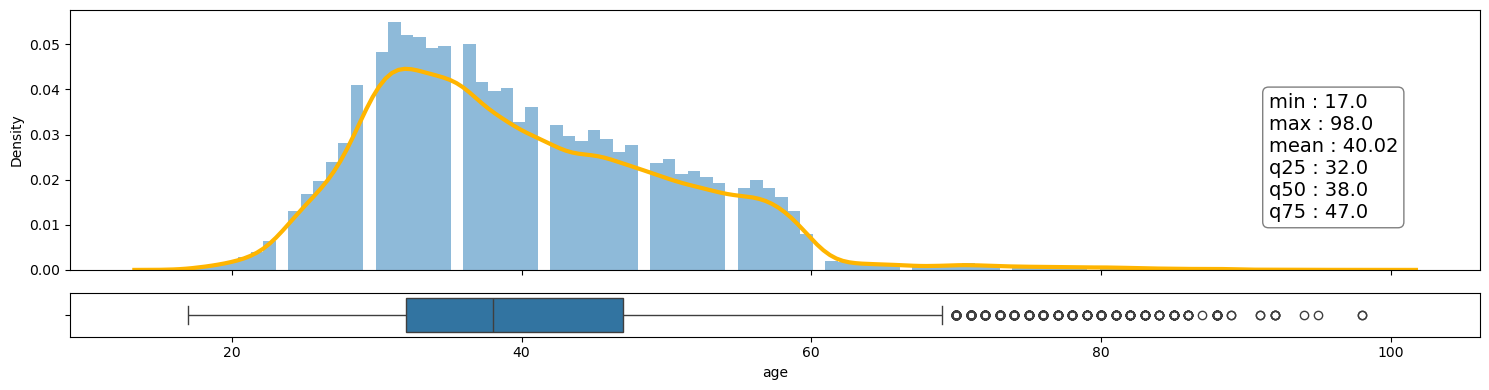

In [ ]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(15, 4), gridspec_kw={'height_ratios':[3, 0.5]})
sns.histplot(client_df['age'], stat='density', kde=True, lw=0, ax=ax[0]);
sns.kdeplot(client_df['age'], color='#ffb500', lw=3, ax=ax[0]);

# Add text for features descriptive statistics
_, mean_val, _, min_val, q25, median, q75, max_val = np.round(client_df['age'].describe(), 2)
features_stats_text = f"min : {min_val}\nmax : {max_val}\nmean : {mean_val}\nq25 : {q25}\nq50 : {median}\nq75 : {q75}"
box = dict(boxstyle='round', alpha=0.5, fc='white', ec='k')
x_coor, y_coor = np.quantile(ax[0].get_xlim(), 0.85), np.quantile(ax[0].get_ylim(), 0.2)

ax[0].text(x_coor, y_coor, features_stats_text, fontsize=14, color='k', bbox=box);

sns.boxplot(data = client_df, x ='age', ax=ax[1]);
plt.tight_layout();